
# How many people have ever lived? A Bayesian prior-predictive model

**Method.** We use the standard three-input-class demographic accounting identity
(Fucks/Winkler/Keyfitz; Population Reference Bureau):

$$
\text{Total ever born} = P_{\text{start}} + \sum_{i} \text{CBR}_i \cdot \bar{P}_i \cdot \Delta t_i
$$

where for each historical interval $i$: $\text{CBR}_i$ is the crude birth rate
(births per 1,000 people per year), $\bar{P}_i$ is the average population during
the interval, and $\Delta t_i$ is its duration in years. $P_\text{start}$ is the
founding population at the start date, which is already "born" and must be
added once rather than derived from a birth rate.

**Why this is a prior-predictive simulation, not posterior inference.** There is
no observed data being conditioned on here — we are not updating beliefs against
a likelihood, we are *propagating* uncertainty in the inputs through a fixed,
known formula to get a distribution over the output. That is exactly what
`pm.sample_prior_predictive()` is for. Running `pm.sample()` (NUTS) on this model
would technically work but would be pointless — there is no likelihood term, so
the "posterior" would just be the prior, sampled far less efficiently than
direct forward simulation. This distinction also resolves the frequentist/Bayesian
question from before: there is no natural repeated-sampling frame for a
one-off historical quantity like this, so a *credible interval* built by
propagating explicit, stated prior uncertainty is the more coherent object than
a *confidence interval*.

**The three input classes, each of which can take any of three prior families:**

1. **Starting date** for anatomically modern humans (~190,000–200,000 BCE)
2. **Population size** at a series of historical anchor points
3. **Crude birth rate (CBR)** for each interval between anchor points

**Three prior families:**

- **Log-normal** — supported on $(0, \infty)$, right-skewed, no upper bound.
  Standard choice for a positive quantity you know "to within a multiplicative
  factor." Its cost: it always assigns *some* probability, however small, to
  values arbitrarily far above your stated range — which can matter a lot once
  you multiply and sum a dozen of these together. Appropriate when the "bound"
  you'd otherwise state is really just current best belief and the field has
  been wrong about it before (paradigm-shift risk, not parameter noise).
- **"Beta-ish"** — meaning a `Beta(α, β)` distribution *affinely rescaled* onto a
  hard-bounded interval `[low, high]` you choose from domain knowledge (e.g., a
  population can't plausibly have exceeded some historical carrying-capacity
  ceiling). We parameterize it by a target **mean** and a **concentration**
  parameter `κ` (higher = more tightly clustered around the mean), then convert
  to the corresponding `(α, β)`. Unlike log-normal, mass is *strictly zero*
  outside `[low, high]` — appropriate when a real ceiling exists and you
  basically know where it is (e.g. well-attested census-era populations,
  or crude birth rate, which has a genuine biological ceiling).
- **Truncated log-normal** — a log-normal shape with a hard upper `cap` applied
  (`pm.Truncated(pm.LogNormal.dist(...), upper=cap)`). This is the useful
  middle ground: you want log-normal's realistic multiplicative/skewed shape,
  but you do have one piece of information you're not willing to violate (e.g.
  "population at 3000 BCE definitely didn't exceed 35 million — that's
  archaeologically indefensible — but I'm not ready to commit to a symmetric
  bounded shape either"). Note this is an approximation: calibrating `(mu,
  sigma)` from the pre-truncation mean and then truncating means the
  *realized* mean after truncation is slightly lower than the nominal target
  — fine for a working model, worth correcting if you need exact calibration.

**Hybrid, canonical model.** Rather than force one family onto every parameter,
the model built below assigns a family **per parameter**, based on how well
each period of history is actually attested:

| Period | Population | Birth rate | Family | Why |
|---|---|---|---|---|
| Founding / start date | ✓ | — | Log-normal | Deep prehistory, genuinely open-ended — origin dates have shifted by 140,000 years within living memory of the field |
| Founding → 8,000 BCE | — | ✓ | Log-normal | Same reasoning: earliest, most speculative era |
| 8,000 BCE, 3,000 BCE | ✓ | ✓ | Truncated log-normal | Archaeological carrying-capacity estimates: skewed uncertainty, but a defensible ceiling exists |
| 1 CE onward | ✓ | ✓ | Beta-ish | Written records, censuses, vital statistics — real bounds, well known |

This hybrid is the **canonical model going forward** — the pure log-normal and
pure Beta-ish models are kept below only as a reference/sensitivity check, not
as ongoing alternatives to maintain.

Everything numeric below (population anchors, birth rates, ranges) is an
**illustrative starting point** loosely patterned on commonly-cited historical
population reconstructions (e.g. McEvedy & Jones' *Atlas of World Population
History*, UN World Population Prospects, and the PRB/Haub lineage) — not a
literature-vetted set of point estimates. Swap in your own researched values
before treating the output as more than a worked methodological example.


In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

%matplotlib inline

print("PyMC version:", pm.__version__)
assert pm.__version__.startswith("6."), "This notebook targets the PyMC 6.x API (written/tested against 6.3.1)."

RNG_SEED = 20240826
N_PRIOR_SAMPLES = 20_000

PyMC version: 6.3.1



## 1. Input data: population anchors and birth-rate intervals

`ANCHORS[0]` is the founding population at the (uncertain) start date — its
`year` is `None` because the start date is itself a random variable, handled
separately. Every other anchor has a fixed calendar year (astronomical year
numbering: negative = BCE) with an uncertain population.

`INTERVALS[j]` gives the crude birth rate between `ANCHORS[j]` and `ANCHORS[j+1]`.

Each anchor/interval now also carries a `family` field (and `cap` where
relevant) used **only** by the hybrid model — the pure log-normal and pure
Beta-ish models ignore these fields entirely and apply their single global
family to every parameter, exactly as before.


In [2]:
ANCHORS = [
    dict(label="start_founding",   year=None,   pop_mean=1.0e4,  pop_low=1.0e3,  pop_high=1.0e5,
         family="lognormal"),
    dict(label="8000BCE_agri",     year=-8000,  pop_mean=5.0e6,  pop_low=1.0e6,  pop_high=1.0e7,
         family="truncated_lognormal", cap=1.5e7),
    dict(label="3000BCE_bronze",   year=-3000,  pop_mean=1.4e7,  pop_low=1.0e7,  pop_high=2.0e7,
         family="truncated_lognormal", cap=3.5e7),
    dict(label="1CE",              year=1,      pop_mean=3.0e8,  pop_low=1.7e8,  pop_high=4.0e8,
         family="beta"),
    dict(label="1000CE",           year=1000,   pop_mean=3.1e8,  pop_low=2.65e8, pop_high=3.45e8,
         family="beta"),
    dict(label="1500CE",           year=1500,   pop_mean=5.0e8,  pop_low=4.25e8, pop_high=5.4e8,
         family="beta"),
    dict(label="1650CE",           year=1650,   pop_mean=5.5e8,  pop_low=4.7e8,  pop_high=6.0e8,
         family="beta"),
    dict(label="1750CE",           year=1750,   pop_mean=8.0e8,  pop_low=7.2e8,  pop_high=9.5e8,
         family="beta"),
    dict(label="1850CE",           year=1850,   pop_mean=1.26e9, pop_low=1.20e9, pop_high=1.30e9,
         family="beta"),
    dict(label="1900CE",           year=1900,   pop_mean=1.65e9, pop_low=1.60e9, pop_high=1.70e9,
         family="beta"),
    dict(label="1950CE",           year=1950,   pop_mean=2.50e9, pop_low=2.45e9, pop_high=2.55e9,
         family="beta"),
    dict(label="2000CE",           year=2000,   pop_mean=6.10e9, pop_low=6.00e9, pop_high=6.20e9,
         family="beta"),
    dict(label="2024CE",           year=2024,   pop_mean=8.10e9, pop_low=8.00e9, pop_high=8.20e9,
         family="beta"),
]

INTERVALS = [
    dict(cbr_mean=80, cbr_low=60, cbr_high=95, family="lognormal"),                    # founding -> 8000 BCE
    dict(cbr_mean=70, cbr_low=55, cbr_high=85, family="truncated_lognormal", cap=95),   # 8000 -> 3000 BCE
    dict(cbr_mean=60, cbr_low=45, cbr_high=75, family="truncated_lognormal", cap=90),   # 3000 BCE -> 1 CE
    dict(cbr_mean=55, cbr_low=40, cbr_high=70, family="beta"),                          # 1 -> 1000 CE
    dict(cbr_mean=55, cbr_low=40, cbr_high=70, family="beta"),                          # 1000 -> 1500 CE
    dict(cbr_mean=50, cbr_low=35, cbr_high=60, family="beta"),                          # 1500 -> 1650 CE
    dict(cbr_mean=45, cbr_low=35, cbr_high=55, family="beta"),                          # 1650 -> 1750 CE
    dict(cbr_mean=42, cbr_low=35, cbr_high=50, family="beta"),                          # 1750 -> 1850 CE
    dict(cbr_mean=38, cbr_low=32, cbr_high=45, family="beta"),                          # 1850 -> 1900 CE
    dict(cbr_mean=33, cbr_low=28, cbr_high=40, family="beta"),                          # 1900 -> 1950 CE
    dict(cbr_mean=28, cbr_low=20, cbr_high=35, family="beta"),                          # 1950 -> 2000 CE
    dict(cbr_mean=19, cbr_low=16, cbr_high=22, family="beta"),                          # 2000 -> 2024 CE
]

assert len(INTERVALS) == len(ANCHORS) - 1

# A quick audit table of the hybrid model's per-parameter family assignment,
# so the assignment is always visible and easy to double-check, not buried in code.
audit_rows = [dict(parameter=f"pop[{a['label']}]", family=a["family"], cap=a.get("cap", "")) for a in ANCHORS]
audit_rows += [dict(parameter=f"cbr[interval {j}]", family=iv["family"], cap=iv.get("cap", ""))
               for j, iv in enumerate(INTERVALS)]
pd.DataFrame(audit_rows)

,parameter,family,cap
0,pop[start_founding],lognormal,
1,pop[8000BCE_agri],truncated_lognormal,15000000.0
2,pop[3000BCE_bronze],truncated_lognormal,35000000.0
3,pop[1CE],beta,
4,pop[1000CE],beta,
5,pop[1500CE],beta,
6,pop[1650CE],beta,
7,pop[1750CE],beta,
8,pop[1850CE],beta,
9,pop[1900CE],beta,



## 2. Prior-parameterization helpers

Both helpers take a **mean** and a **[low, high] range** (read as roughly a
90–95%-ish plausible band from your own judgment/literature) and return the
distribution parameters that reproduce that mean with that spread — so the
*inputs you reason about* (mean, plausible range) are the same for both prior
families, and only the *shape* (unbounded vs. hard-bounded) differs.


In [3]:
def lognormal_params(mean, low, high, z=1.96):
    '''(mu, sigma) for a LogNormal with the given arithmetic mean, calibrated
    so that [low, high] corresponds to roughly a central (1 - 2*Phi(-z)) interval
    (z=1.96 -> ~95%, z=1.645 -> ~90% one-sided).'''
    sigma = (np.log(high) - np.log(low)) / (2 * z)
    mu = np.log(mean) - 0.5 * sigma**2
    return mu, sigma


def betaish_params(mean, low, high, kappa=8.0):
    '''(alpha, beta) for a Beta distribution such that, after rescaling via
    low + (high - low) * Beta(alpha, beta), the result has the given mean and
    is supported ONLY on [low, high]. kappa = alpha + beta controls how tightly
    mass clusters around the mean (higher kappa -> narrower, more peaked).'''
    p = (mean - low) / (high - low)
    assert 0 < p < 1, "mean must lie strictly inside [low, high]"
    alpha = p * kappa
    beta_ = (1 - p) * kappa
    return alpha, beta_


## 3. Building the model

`build_model(prior_family, kappa)` constructs the full PyMC model. It supports
three values of `prior_family`:

- `"lognormal"` — every parameter gets an (open-tailed) log-normal prior.
- `"beta"` — every parameter gets a hard-bounded Beta-ish prior.
- `"hybrid"` — **the canonical model.** Each parameter reads its own `family`
  (and `cap`, if any) from the `ANCHORS`/`INTERVALS` tables defined above,
  so the assignment lives with the data, not buried in branching logic.

A shared helper, `make_bounded_positive_prior`, builds a single parameter in
whichever of the three families is requested — including the new
**truncated log-normal** (`pm.Truncated(pm.LogNormal.dist(mu, sigma), upper=cap)`),
which keeps log-normal's skewed shape but hard-caps the upper tail.

A few modeling notes that still apply as before:

- **Start date.** Under `"lognormal"` and `"hybrid"`, we model
  `extra_years_before_190kya` — how much earlier than 190,000 BCE the true
  origin might be — as LogNormal with a long right tail (open-ended, since
  origin-date estimates have shifted by well over 100,000 years within the
  field's living memory). Under pure `"beta"`, 190,000–200,000 BCE is instead
  a hard bound with zero probability outside it.
- **Average population per interval.** Assuming exponential (geometric) growth
  within an interval, the correct average of a quantity growing exponentially
  between $P_a$ and $P_b$ is the **logarithmic mean** $(P_b - P_a) / (\ln P_b - \ln P_a)$,
  not the arithmetic mean — we fall back to the arithmetic mean only in the
  degenerate case $P_a \approx P_b$ to avoid a 0/0.
- **Total.** `total_ever_born = founding population + sum of interval births`.
  Consistent with the demographic literature, this does **not** depend on death
  rates at all — only on births.


In [4]:
def logarithmic_mean(p_a, p_b):
    diff = p_b - p_a
    logdiff = pm.math.log(p_b) - pm.math.log(p_a)
    return pm.math.switch(pt.abs(diff) < 1.0, (p_a + p_b) / 2.0, diff / logdiff)


def make_bounded_positive_prior(name, family, mean, low, high, kappa=8.0, z=1.96, cap=None):
    '''Build a single positive-valued PyMC prior in one of three families:
      - "lognormal": open right tail, calibrated from (mean, low, high)
      - "beta": hard-bounded on [low, high] via a rescaled Beta ("Beta-ish")
      - "truncated_lognormal": lognormal shape, hard-capped at `cap`
    Returns a pytensor variable for the quantity itself, on its natural scale.'''
    if family == "lognormal":
        mu, sigma = lognormal_params(mean, low, high, z=z)
        return pm.LogNormal(name, mu=mu, sigma=sigma)
    elif family == "truncated_lognormal":
        assert cap is not None, f"{name}: truncated_lognormal requires a cap"
        mu, sigma = lognormal_params(mean, low, high, z=z)
        return pm.Truncated(name, pm.LogNormal.dist(mu=mu, sigma=sigma), upper=cap)
    elif family == "beta":
        alpha, beta_ = betaish_params(mean, low, high, kappa=kappa)
        frac = pm.Beta(name + "_frac", alpha=alpha, beta=beta_)
        return pm.Deterministic(name, low + frac * (high - low))
    else:
        raise ValueError(f"unknown prior family: {family!r}")


def build_model(prior_family="hybrid", kappa=8.0, z=1.96):
    assert prior_family in ("lognormal", "beta", "hybrid")

    with pm.Model() as model:

        # ---- Input class 1: starting date -----------------------------------
        if prior_family == "beta":
            a_s, b_s = betaish_params(mean=195_000, low=190_000, high=200_000, kappa=kappa)
            start_frac = pm.Beta("start_frac", alpha=a_s, beta=b_s)
            start_year = pm.Deterministic("start_year", -200_000 + start_frac * 10_000)
        else:  # "lognormal" and "hybrid" both use the open-tailed start date
            mu_e, sigma_e = lognormal_params(mean=5000, low=200, high=10000, z=1.645)
            extra_years = pm.LogNormal("extra_years_before_190kya", mu=mu_e, sigma=sigma_e)
            start_year = pm.Deterministic("start_year", -190_000 - extra_years)

        # ---- Input class 2: population at each anchor -----------------------
        pops = []
        for i, a in enumerate(ANCHORS):
            name = f"pop_{i}_{a['label']}"
            family = a["family"] if prior_family == "hybrid" else prior_family
            cap = a.get("cap") if prior_family == "hybrid" else None
            p_i = make_bounded_positive_prior(
                name, family, a["pop_mean"], a["pop_low"], a["pop_high"], kappa=kappa, z=z, cap=cap
            )
            pops.append(p_i)

        # ---- Input class 3: birth rate for each interval, then births -------
        births_list = []
        for j, iv in enumerate(INTERVALS):
            name = f"cbr_{j}"
            family = iv["family"] if prior_family == "hybrid" else prior_family
            cap = iv.get("cap") if prior_family == "hybrid" else None
            cbr = make_bounded_positive_prior(
                name, family, iv["cbr_mean"], iv["cbr_low"], iv["cbr_high"], kappa=kappa, z=z, cap=cap
            )

            p_a, p_b = pops[j], pops[j + 1]
            year_a = start_year if j == 0 else ANCHORS[j]["year"]
            year_b = ANCHORS[j + 1]["year"]
            duration = year_b - year_a

            avg_pop = logarithmic_mean(p_a, p_b)
            births_j = pm.Deterministic(f"births_{j}", (cbr / 1000.0) * avg_pop * duration)
            births_list.append(births_j)

        total_births = pm.math.sum(pt.stack(births_list))
        total_ever_born = pm.Deterministic("total_ever_born", pops[0] + total_births)
        pct_alive_today = pm.Deterministic(
            "pct_alive_today", 100.0 * pops[-1] / total_ever_born
        )

    return model


## 4. Monte Carlo propagation (prior-predictive sampling)

This is the whole "Monte Carlo propagation" step: draw many independent samples
from all the priors, push each draw through the deterministic accounting
formula, and look at the resulting distribution of `total_ever_born`.


In [5]:
model_lognormal = build_model(prior_family="lognormal")
model_beta = build_model(prior_family="beta", kappa=8.0)
model_hybrid = build_model(prior_family="hybrid", kappa=8.0)

with model_lognormal:
    prior_lognormal = pm.sample_prior_predictive(draws=N_PRIOR_SAMPLES, random_seed=RNG_SEED)

with model_beta:
    prior_beta = pm.sample_prior_predictive(draws=N_PRIOR_SAMPLES, random_seed=RNG_SEED)

with model_hybrid:
    prior_hybrid = pm.sample_prior_predictive(draws=N_PRIOR_SAMPLES, random_seed=RNG_SEED)

totals_ln = prior_lognormal.prior["total_ever_born"].values.flatten()
totals_be = prior_beta.prior["total_ever_born"].values.flatten()
totals_hy = prior_hybrid.prior["total_ever_born"].values.flatten()

pct_alive_ln = prior_lognormal.prior["pct_alive_today"].values.flatten()
pct_alive_be = prior_beta.prior["pct_alive_today"].values.flatten()
pct_alive_hy = prior_hybrid.prior["pct_alive_today"].values.flatten()

print(f"Lognormal draws: {totals_ln.shape[0]:,}   Beta-ish draws: {totals_be.shape[0]:,}   Hybrid draws: {totals_hy.shape[0]:,}")

Sampling: [cbr_0, cbr_1, cbr_10, cbr_11, cbr_2, cbr_3, cbr_4, cbr_5, cbr_6, cbr_7, cbr_8, cbr_9, extra_years_before_190kya, pop_0_start_founding, pop_10_1950CE, pop_11_2000CE, pop_12_2024CE, pop_1_8000BCE_agri, pop_2_3000BCE_bronze, pop_3_1CE, pop_4_1000CE, pop_5_1500CE, pop_6_1650CE, pop_7_1750CE, pop_8_1850CE, pop_9_1900CE]


Sampling: [cbr_0_frac, cbr_10_frac, cbr_11_frac, cbr_1_frac, cbr_2_frac, cbr_3_frac, cbr_4_frac, cbr_5_frac, cbr_6_frac, cbr_7_frac, cbr_8_frac, cbr_9_frac, pop_0_start_founding_frac, pop_10_1950CE_frac, pop_11_2000CE_frac, pop_12_2024CE_frac, pop_1_8000BCE_agri_frac, pop_2_3000BCE_bronze_frac, pop_3_1CE_frac, pop_4_1000CE_frac, pop_5_1500CE_frac, pop_6_1650CE_frac, pop_7_1750CE_frac, pop_8_1850CE_frac, pop_9_1900CE_frac, start_frac]


Sampling: [cbr_0, cbr_1, cbr_10_frac, cbr_11_frac, cbr_2, cbr_3_frac, cbr_4_frac, cbr_5_frac, cbr_6_frac, cbr_7_frac, cbr_8_frac, cbr_9_frac, extra_years_before_190kya, pop_0_start_founding, pop_10_1950CE_frac, pop_11_2000CE_frac, pop_12_2024CE_frac, pop_1_8000BCE_agri, pop_2_3000BCE_bronze, pop_3_1CE_frac, pop_4_1000CE_frac, pop_5_1500CE_frac, pop_6_1650CE_frac, pop_7_1750CE_frac, pop_8_1850CE_frac, pop_9_1900CE_frac]


Lognormal draws: 20,000   Beta-ish draws: 20,000   Hybrid draws: 20,000



## 5. Summary: credible intervals and comparison


In [6]:
def summarize(samples, label):
    billions = samples / 1e9
    hdi_94 = az.hdi(billions, prob=0.94)
    return {
        "prior family": label,
        "mean (B)": np.mean(billions),
        "median (B)": np.median(billions),
        "sd (B)": np.std(billions),
        "95% CI low (B)": np.percentile(billions, 2.5),
        "95% CI high (B)": np.percentile(billions, 97.5),
        "94% HDI low (B)": hdi_94[0],
        "94% HDI high (B)": hdi_94[1],
    }

summary_df = pd.DataFrame([
    summarize(totals_ln, "Log-normal (all params)"),
    summarize(totals_be, "Beta-ish (all params)"),
    summarize(totals_hy, "Hybrid (canonical)"),
]).set_index("prior family").round(2)

summary_df

,mean (B),median (B),sd (B),95% CI low (B),95% CI high (B),94% HDI low (B),94% HDI high (B)
prior family,,,,,,,
Log-normal (all params),84.43,83.29,9.46,69.29,105.87,68.34,102.05
Beta-ish (all params),85.13,85.00,5.34,75.07,96.01,75.24,95.25
Hybrid (canonical),84.10,83.21,7.53,71.77,101.27,70.83,98.25


In [7]:
pct_alive_df = pd.DataFrame([
    {
        "prior family": "Log-normal (all params)",
        "mean % alive today": np.mean(pct_alive_ln),
        "95% CI low": np.percentile(pct_alive_ln, 2.5),
        "95% CI high": np.percentile(pct_alive_ln, 97.5),
    },
    {
        "prior family": "Beta-ish (all params)",
        "mean % alive today": np.mean(pct_alive_be),
        "95% CI low": np.percentile(pct_alive_be, 2.5),
        "95% CI high": np.percentile(pct_alive_be, 97.5),
    },
    {
        "prior family": "Hybrid (canonical)",
        "mean % alive today": np.mean(pct_alive_hy),
        "95% CI low": np.percentile(pct_alive_hy, 2.5),
        "95% CI high": np.percentile(pct_alive_hy, 97.5),
    },
]).set_index("prior family").round(2)

pct_alive_df

,mean % alive today,95% CI low,95% CI high
prior family,,,
Log-normal (all params),9.71,7.65,11.69
Beta-ish (all params),9.55,8.43,10.79
Hybrid (canonical),9.71,7.99,11.29



## 6. Visual comparison


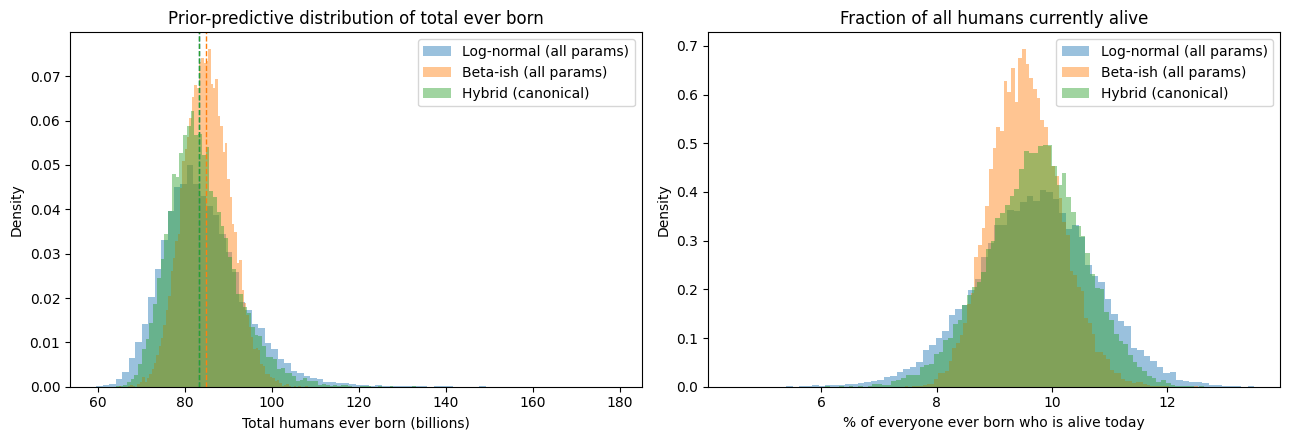

In [8]:
colors = {"ln": "tab:blue", "be": "tab:orange", "hy": "tab:green"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(totals_ln / 1e9, bins=80, alpha=0.45, label="Log-normal (all params)", color=colors["ln"], density=True)
axes[0].hist(totals_be / 1e9, bins=80, alpha=0.45, label="Beta-ish (all params)", color=colors["be"], density=True)
axes[0].hist(totals_hy / 1e9, bins=80, alpha=0.45, label="Hybrid (canonical)", color=colors["hy"], density=True)
axes[0].axvline(np.median(totals_ln) / 1e9, color=colors["ln"], linestyle="--", linewidth=1)
axes[0].axvline(np.median(totals_be) / 1e9, color=colors["be"], linestyle="--", linewidth=1)
axes[0].axvline(np.median(totals_hy) / 1e9, color=colors["hy"], linestyle="--", linewidth=1)
axes[0].set_xlabel("Total humans ever born (billions)")
axes[0].set_ylabel("Density")
axes[0].set_title("Prior-predictive distribution of total ever born")
axes[0].legend()

axes[1].hist(pct_alive_ln, bins=80, alpha=0.45, label="Log-normal (all params)", color=colors["ln"], density=True)
axes[1].hist(pct_alive_be, bins=80, alpha=0.45, label="Beta-ish (all params)", color=colors["be"], density=True)
axes[1].hist(pct_alive_hy, bins=80, alpha=0.45, label="Hybrid (canonical)", color=colors["hy"], density=True)
axes[1].set_xlabel("% of everyone ever born who is alive today")
axes[1].set_ylabel("Density")
axes[1].set_title("Fraction of all humans currently alive")
axes[1].legend()

plt.tight_layout()
plt.show()


### Where the hybrid model lands

The model multiplies and sums roughly two dozen independent uncertain
quantities. Log-normal's unbounded upper tail means a Monte Carlo draw can,
purely by chance, combine several simultaneously-high values (a high founding
population *and* a high Paleolithic birth rate *and* an early start date) with
no ceiling stopping it — fattening the upper tail of `total_ever_born`. The
pure Beta-ish model caps every input, so that compounding is capped too,
giving the narrowest interval of the three. The **hybrid** should land between
the two pure models, but closer to Beta-ish — since only 5 of the ~27
parameters (the founding population, the start date, and the two earliest
population/birth-rate pairs) keep an open or semi-open tail; everything from
1 CE onward is hard-bounded. Check `summary_df` above to confirm this pattern
and see the actual magnitude.



## 7. Illustrating the shape difference directly (starting date)

This plots the two starting-date priors' densities analytically (not from
samples) so the bounded-vs-tailed distinction is visually obvious.


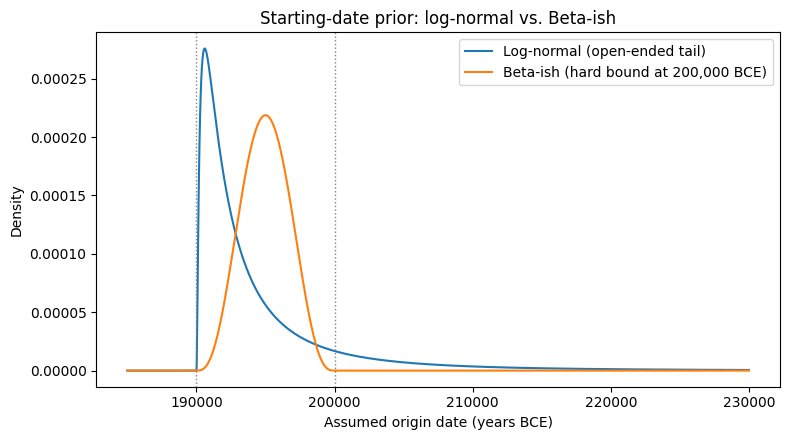

In [9]:
from scipy import stats

years_bce = np.linspace(185_000, 230_000, 2000)

mu_e, sigma_e = lognormal_params(mean=5000, low=200, high=10000, z=1.645)
extra = years_bce - 190_000
ln_density = np.where(
    extra > 0,
    stats.lognorm(s=sigma_e, scale=np.exp(mu_e)).pdf(extra),
    0.0,
)

a_s, b_s = betaish_params(mean=195_000, low=190_000, high=200_000, kappa=8.0)
frac = (years_bce - 190_000) / 10_000
beta_density = np.where(
    (frac >= 0) & (frac <= 1),
    stats.beta(a_s, b_s).pdf(np.clip(frac, 1e-9, 1 - 1e-9)) / 10_000,
    0.0,
)

plt.figure(figsize=(8, 4.5))
plt.plot(years_bce, ln_density, label="Log-normal (open-ended tail)", color="tab:blue")
plt.plot(years_bce, beta_density, label="Beta-ish (hard bound at 200,000 BCE)", color="tab:orange")
plt.axvline(190_000, color="gray", linestyle=":", linewidth=1)
plt.axvline(200_000, color="gray", linestyle=":", linewidth=1)
plt.xlabel("Assumed origin date (years BCE)")
plt.ylabel("Density")
plt.title("Starting-date prior: log-normal vs. Beta-ish")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Takeaways and next steps

- **`model_hybrid` is the canonical model to keep iterating on.** The pure
  log-normal and pure Beta-ish models are retained purely as a one-time
  robustness/sensitivity check ("does the conclusion hinge on this modeling
  choice?"), not as parallel models to maintain going forward. If you only
  want to run one model from here, run the hybrid.
- **The per-parameter family assignment is itself a modeling choice, and it's
  now explicit and auditable** — see the assignment table printed in Section 1
  and the rationale table in Section 3. If you disagree with a specific
  assignment (e.g. you think 1 CE population deserves a truncated log-normal
  rather than Beta-ish, given how much historical population estimates for
  antiquity still disagree), change that one `family`/`cap` entry in `ANCHORS`
  or `INTERVALS` — the model logic doesn't need to change.
- **This is still a methodology demonstration, not a finished estimate.** The
  anchor populations, birth rates, and `cap` values are illustrative
  placeholders. Before treating the output numbers as meaningful, replace them
  with values you've actually sourced (McEvedy & Jones, UN WPP, Livi-Bacci,
  the PRB/Haub CBR-by-era table, Kremer 1993, etc.), and set the `[low, high]`
  ranges — and the truncation `cap`s — to reflect real disagreement across
  sources for each period, not a guessed spread.
- **The credible interval is only as good as the prior elicitation.** Because
  this is a forward simulation with no data to correct it, there's no "learning"
  step — garbage in, garbage out, with a nice-looking histogram around it. The
  main value of doing it this way over a single point estimate is that it forces
  you to be explicit about *which* uncertainties you think matter and by how
  much, and shows you which of the ~27 uncertain inputs actually drives the
  width of the final interval (worth checking via a one-at-a-time sensitivity
  sweep, or by inspecting prior correlations between each input and
  `total_ever_born`).
- **`kappa` and the truncation `cap`s are knobs, not laws of nature.** Try a
  few values of `kappa` (e.g. 4 vs 8 vs 20) and a few `cap` choices for the
  truncated parameters, and see how much the hybrid model's final interval
  moves — that sensitivity is itself informative, and worth reporting alongside
  the headline interval.
- **Possible extensions:** (1) replace the single-point CBR-per-interval with
  its own uncertain trajectory rather than a constant within each interval;
  (2) add a stochastic/jump component to population trajectories to capture
  plagues and famines rather than assuming smooth exponential interpolation
  between anchors; (3) treat the best-attested anchors (e.g. 2024 population)
  as effectively known constants rather than random, since we do have that
  data precisely, tightening the overall interval without changing the method;
  (4) correct the truncated log-normal's mean-shift-from-truncation noted in
  Section 0 if exact calibration matters for your purposes.
